

**Dataset:** Breast Cancer (Wisconsin) from `scikit-learn`

**Tools:** `pandas`, `numpy`, `matplotlib`, `scikit-learn`



> 1. Using **matplotlib** only for Visualization (no seaborn).  


## 1. Environment setup

**Instructions**
1. Import: `numpy as np`, `pandas as pd`, `matplotlib.pyplot as plt`.
2. From `sklearn`, import:  
   - `datasets` (to load data)  
   - `model_selection` (for train/test split & cross-validation)  
   - `preprocessing` (`StandardScaler`)  
   - `metrics` (for evaluation)  
   - `linear_model` (`LogisticRegression`)  
   - `tree` (`DecisionTreeClassifier`)  
   - `pipeline` (`Pipeline`)
3. Set a random seed (e.g., `RANDOM_STATE = 42`).  
4. Configure matplotlib for inline plotting with `plt.rcParams["figure.figsize"] = (6,4)`.



In [ ]:
# Install required libraries (run this cell if not already installed)
%pip install numpy pandas matplotlib scikit-learn 

In [19]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (6,4)


## 2. Load dataset & build a DataFrame
**Instructions**
1. Load the Breast Cancer (Wisconsin) dataset using `datasets.load_breast_cancer(as_frame=True)`.
2. Create:
   - `X` as a `DataFrame` of features
   - `y` as a `Series` of labels
   - `df` combining features + a new column `target` (0 = malignant, 1 = benign per `sklearn`).
3. Show `df.head(3)` and `df.shape` to confirm structure.
4. Print the mapping of target codes to label names (from the dataset’s `target_names`).


In [22]:
load_breast_cancer()["target_names"]

array(['malignant', 'benign'], dtype='<U9')

In [23]:

canser = load_breast_cancer(as_frame = True)
df = canser.frame
print("Shape: ",df.shape)
df.head(3)


Shape:  (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [24]:

y = df['target']
X = df.drop(columns = "target")
X.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [25]:
print(" 0 = malignant, 1 = benign per sklearn in target_names value:")
print(load_breast_cancer()["target_names"])
target_classes = {
    0: {"label": "malignant", "color": "#1f77b4"},  # Classic blue
    1: {"label": "benign", "color": "#ff7f0e"}     # Classic orange
}

 0 = malignant, 1 = benign per sklearn in target_names value:
['malignant' 'benign']


In [26]:
y

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64

## 3. Quick data audit & class balance
**Instructions**
1. Check for missing values per column and overall.
2. Show basic stats with `df.describe()` (for numeric columns).
3. Compute and print class counts (`y.value_counts()`).
4. **Plot** a simple **bar chart** of class counts (`malignant` vs `benign`).  



In [27]:
# nan values:
print(df.isna().sum().sum())
print(y.value_counts())
df.describe()

0
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


<BarContainer object of 2 artists>

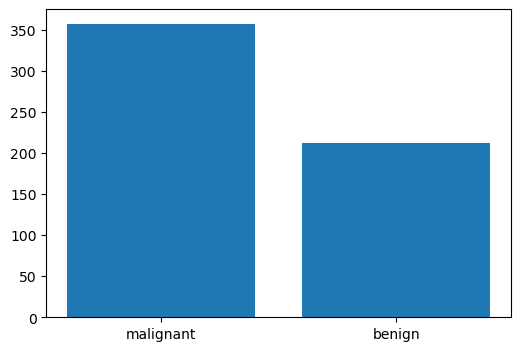

In [28]:
counts = y.value_counts()

# 2. Convert index to string to force categorical plotting
categories = ["malignant", "benign"]
plt.bar(categories,y.value_counts())

## 4. Feature distribution

**Instructions**
1. Choose one informative feature, e.g., `mean radius`.
2. **Plot 1:** A histogram of that feature for the **entire dataset**.  
3. **Plot 2:** An **overlaid** histogram of the same feature **by class** (malignant vs benign).  
   - Use default colors (don’t set any), and `alpha` for transparency if needed.
   - Keep **one figure per plot** (i.e., two code cells or two calls separated).



(array([ 19.,  79., 185., 129.,  55.,  50.,  38.,   7.,   4.,   3.]),
 array([ 6.981 ,  9.0939, 11.2068, 13.3197, 15.4326, 17.5455, 19.6584,
        21.7713, 23.8842, 25.9971, 28.11  ]),
 <BarContainer object of 10 artists>)

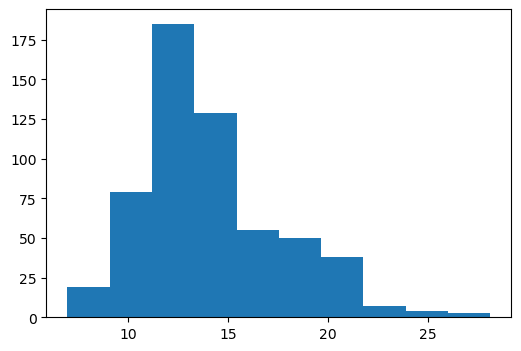

In [29]:
# Plot 1: overall histogram 
plt.hist(df['mean radius'])

In [30]:
df[df["target"]== 0]["mean radius"]

0      17.99
1      20.57
2      19.69
3      11.42
4      20.29
       ...  
563    20.92
564    21.56
565    20.13
566    16.60
567    20.60
Name: mean radius, Length: 212, dtype: float64

(array([ 4., 15., 35., 54., 90., 78., 50., 23.,  6.,  2.]),
 array([ 6.981 ,  8.0679,  9.1548, 10.2417, 11.3286, 12.4155, 13.5024,
        14.5893, 15.6762, 16.7631, 17.85  ]),
 <BarContainer object of 10 artists>)

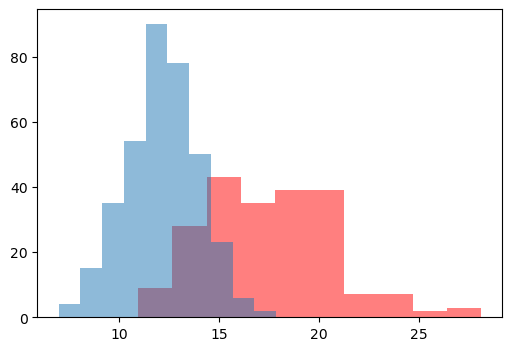

In [31]:
# Plot 2: overlaid histogram by class
plt.hist(df[df["target"]== 0]["mean radius"], color = "red", alpha = 0.5)
plt.hist(df[df["target"]== 1]["mean radius"], alpha = 0.5)

## 5. Feature relationship: scatter plot

**Instructions**
1. Pick two features that are likely related (e.g., `mean radius` vs `mean perimeter`).
2. Create a **scatter plot** with points for each class on the **same figure** (two calls to `plt.scatter`), with labels for the legend.
3. Compute and print the Pearson correlation between the two features.



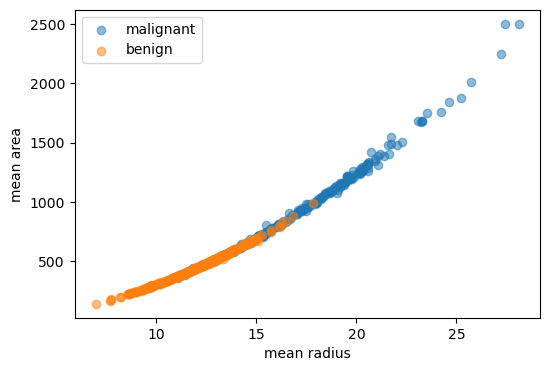

Correlation between mean radius and mean area: 0.9873571700566127


In [36]:
feat_a = df["mean radius"] 
feat_b = df["mean area"]
# target_classes is defined above according as dict with keys 0 and 1, and values as dicts with "label" and "color" keys.
for val, info in target_classes.items():
    plt.scatter(
        feat_a[y == val], 
        feat_b[y == val], 
        c = info["color"], 
        alpha = 0.5, 
        label = info["label"]
    )
    plt.legend()

plt.xlabel("mean radius")

plt.ylabel("mean area")
plt.show()

# correlation:
print("Correlation between mean radius and mean area:", feat_a.corr(feat_b))



## 6. Correlation matrix of top-variance features

**Instructions**
1. Compute column-wise variance on the numeric features (exclude `target`).
2. Select the **top 10** features by variance.
3. Compute the **correlation matrix** of these 10 features.
4. Visualize it with a **single heatmap** using `plt.imshow()` and a colorbar.  
   - Do **not** specify a color map; use defaults.
   - Add readable tick labels (rotate if needed).


Variance of each feature:
 worst area                 324167.39
mean area                  123843.55
area error                   2069.43
worst perimeter              1129.13
mean perimeter                590.44
worst texture                  37.78
worst radius                   23.36
mean texture                   18.50
mean radius                    12.42
perimeter error                 4.09
texture error                   0.30
target                          0.23
radius error                    0.08
worst concavity                 0.04
worst compactness               0.02
mean concavity                  0.01
concavity error                 0.00
concave points error            0.00
symmetry error                  0.00
fractal dimension error         0.00
mean concave points             0.00
mean fractal dimension          0.00
mean compactness                0.00
mean smoothness                 0.00
worst smoothness                0.00
mean symmetry                   0.00
smoothness 

/var/folders/xp/s7v18px54kx6tkf_sxp6d9sh0000gn/T/ipykernel_25522/4058324925.py:17: UserWarning: Adding colorbar to a different Figure <Figure size 600x400 with 2 Axes> than <Figure size 600x400 with 0 Axes> which fig.colorbar is called on.
  plt.figure().colorbar(cax)


[Text(0, 0, 'worst area'),
 Text(0, 1, 'mean area'),
 Text(0, 2, 'area error'),
 Text(0, 3, 'worst perimeter'),
 Text(0, 4, 'mean perimeter'),
 Text(0, 5, 'worst texture'),
 Text(0, 6, 'worst radius'),
 Text(0, 7, 'mean texture'),
 Text(0, 8, 'mean radius'),
 Text(0, 9, 'perimeter error')]

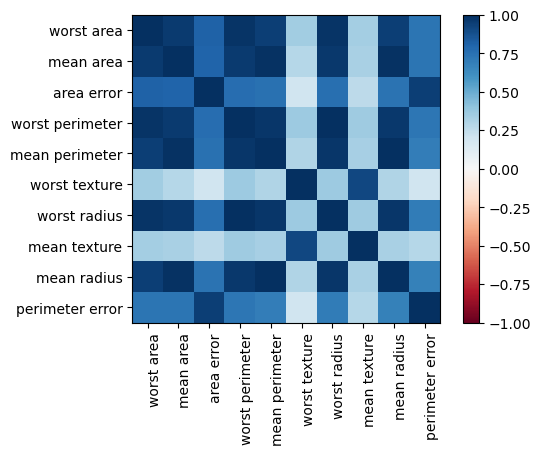

<Figure size 600x400 with 0 Axes>

In [77]:
# 1: Variance of each feature
all_var = df.select_dtypes(include=[np.number]).var().round(2).sort_values(ascending = False)
print("Variance of each feature:\n", all_var)

#2 : top 10 features with highest variance
top10_var = df.select_dtypes(include=[np.number]).var().round(2).sort_values(ascending = False).head(10).index

# 3: correlation matrix of top 10 features
correlation_matrix = df[top10_var].corr()


# print("correlation_matrix of the top 10 features:\n", correlation_matrix)

# 4: heatmap of the correlation matrix
ax = plt.figure().add_subplot()
cax = plt.imshow(correlation_matrix, cmap='RdBu', vmin=-1, vmax=1)
plt.figure().colorbar(cax)


# Maping the variable names to the ticks
ticks = np.arange(0, len(top10_var), 1)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(top10_var, rotation=90, ha='left')
ax.set_yticklabels(top10_var)


